# Run all Evaluations

In [1]:
from pathlib import Path

BASE_DIR = Path("results")

In [ ]:
from inference.rewoo_test.main import main as rewoo_main
from inference.direct_prompting_test.main import main as direct_prompting_main
from inference.react.main import main as react_main
import os 
import shutil

if os.path.exists("results"):
    shutil.rmtree("results")

first_n = 100

rewoo_main(first_n=first_n)
direct_prompting_main(first_n=first_n)
react_main(first_n=first_n)

/opt/miniconda3/envs/MA312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MPS (Metal Performance Shaders) is available! Using Apple Silicon GPU.
Limiting to first 100 samples.
✅ ollama/smollm2:135m: Already evaluated all SVAMP test samples. (100/100 samples evaluated)
Limiting to first 100 samples.
✅ ollama/smollm2:135m: Already evaluated all GSM8K test samples. (100/100 samples evaluated)
Limiting to first 100 samples.
✅ ollama/smollm2:360m: Already evaluated all SVAMP test samples. (100/100 samples evaluated)
Limiting to first 100 samples.
✅ ollama/smollm2:360m: Already evaluated all GSM8K test samples. (100/100 samples evaluated)
Limiting to first 100 samples.
✅ ollama/qwen2.5:0.5b: Already evaluated all SVAMP test samples. (100/100 samples evaluated)
Limiting to first 100 samples.
✅ ollama/qwen2.5:0.5b: Already evaluated all GSM8K test samples. (100/100 samples evaluated)


# Evaluate Runs

## ReWOO

In [ ]:
import pandas as pd
import os


dfs = []
for root, dirs, files in os.walk(BASE_DIR / "rewoo"):
    for file in files:
        fpath = os.path.join(root, file)
        df_r = pd.read_csv(fpath)
        df_r["Method"] = "ReWOO"
        df_r["Model"] = Path(fpath).parent.name + "/" + Path(fpath).stem
        df_r["Dataset"] = Path(fpath).parent.parent.name
        if Path(fpath).parent.parent.name == "SVAMP":
            df_r["target_answer"] = df_r["Equation"] + " = " + df_r["target_answer"].astype(str)
        
        # select columns  Method", "question", "response", "model_history
        df_r = df_r[["Method", "Model", "Dataset", "question", "target_answer", "response", "model_history", "is_correct", "format_correct", "input_tokens", "output_tokens", "total_tokens", "reasoning"]]
        dfs.append(df_r)

df_rewoo = pd.concat(dfs)
df_rewoo.head()

,Method,Model,Dataset,question,target_answer,response,model_history,is_correct,format_correct,input_tokens,output_tokens,total_tokens,reasoning
0,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Winter is almost here and most animals are mig...,( 62.0 - 35.0 ) = 27,-56.0,"[{'plan': {'steps': [['First, calculate how ma...",False,True,318.0,129.0,447.0,"Plan: First, calculate how many bird families ..."
1,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Paige raised 7 goldfish and 12 catfish in the ...,( ( 7.0 + 12.0 ) - 15.0 ) = 4,-5.0,[{'plan': {'steps': [['To find out how many fi...,False,True,291.0,72.0,363.0,"Plan: To find out how many fish disappeared, w..."
2,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Marco and his dad went strawberry picking. Tog...,( ( 22.0 - 36.0 ) + 30.0 ) = 16,-44.0,"[{'plan': {'steps': [[""To find out how much Ma...",False,True,311.0,50.0,361.0,Plan: To find out how much Marco's dad's straw...
3,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Debby bought 200 water bottles and 256 soda bo...,( 256.0 / 4.0 ) = 64,512.0,"[{'plan': {'steps': [['First, calculate how ma...",False,True,303.0,118.0,421.0,"Plan: First, calculate how many water bottles ..."
4,ReWOO,ollama/qwen2.5:0.5b,SVAMP,There were 106 dollars in Olivia's wallet. Aft...,( ( 106.0 - 26.0 ) - 49.0 ) = 31,31.0,[{'plan': {'steps': [['To find out how much Ol...,True,True,303.0,48.0,351.0,Plan: To find out how much Olivia spent at the...


In [6]:
df_rewoo.iloc[0]["reasoning"]

"Plan: First, calculate how many bird families flew away from Asia by subtracting the number of bird families that flew away to Africa from the total number of bird families. Then, calculate how many bird families flew away to Africa by subtracting the number of bird families that flew away to Asia from the total number of bird families.\n\n#E1 = Calculator[41 - (35 + 62)]\n#E2 = Calculator[62 - 35]\n#E3 = Calculator[62 - 35] # This is the same as E1, so we don't need to calculate it again."

In [41]:
from math_datasets.generators import GeminiGenerate, OllamaGenerate

prompt = (
    """## Math Reasoning Error Classification

You are an expert in analyzing mathematical problem-solving. Your task is to identify and classify the specific reasoning error present in a given math word problem solution.

You will be provided with:
1.  **The original math word problem.**
2.  **The incorrect solution to the problem.**

Your goal is to determine which of the following error classes best describes the primary reasoning mistake in the provided solution. Select only **one** ID that most accurately represents the error.

**Available Error Classes:**

* **CA (Calculation Error):** Mistakes in arithmetic or algebraic computations (e.g., incorrect addition, multiplication result).
* **CV (Context Value Error):** Inconsistent or incorrect use of information or values from the problem's context.
* **HA (Hallucination):** Generation of irrelevant or fabricated information not present in the problem.
* **OP (Operator Error):** Incorrect application of a mathematical operator (e.g., using multiplication instead of division).
* **MS (Missing Step):** Omission of a necessary or logically required step crucial for deriving the correct result.
* **CS (Contradictory Step):** The presence of a logical contradiction within the chain of reasoning steps, breaking the consistency of the solution path.

**Output Format:**

Your output should consist of two parts:
1.  The **ID** of the most appropriate error class.
2.  A "Reasoning:" section explaining why you chose that specific error class, detailing the mistake in the solution relative to the problem and the error class definition.

**Example Input:**

**Problem:** Winter is almost here and most animals are migrating to warmer countries. There are 41 bird families living near the mountain. If 35 bird families flew away to asia and 62 bird families flew away to africa How many more bird families flew away to africa than those that flew away to asia?

**Plan to solve the problem:** Plan: Calculate the difference between the number of bird families that flew away to Africa and the number that flew away to Asia.  \n#E1 = Calculator[41 - (35 + 62)].

**Expected Output:**

CV
Reasoning: The problem states that each cake requires 3 eggs, but the solution incorrectly uses the value '2 eggs/cake' in its calculation. This is an inconsistent use of information from the problem's context.

---

**Problem:** {problem}
**Solution:** {reasoning}
"""
)
# generator = GeminiGenerate(model_name="gemini-2.5-flash")

generator = OllamaGenerate(model_name="mathstral")
error_classes = []
error_class_reasoning = []

mini_df_rewoo = df_rewoo.iloc[:100]  # Limit to first 100 rows for testing

def error_classes_identification(row):
    if row["is_correct"]:
        return None
    response = generator.generate(prompt=prompt.format(reasoning=row["reasoning"], problem=row["question"]))
    return response

mini_df_rewoo["error_class"] = mini_df_rewoo.apply(error_classes_identification, axis=1)
mini_df_rewoo.head(10)

/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs00000gn/T/ipykernel_1204/305090170.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mini_df_rewoo["error_class"] = mini_df_rewoo.apply(error_classes_identification, axis=1)


,Method,Model,Dataset,question,target_answer,response,model_history,is_correct,format_correct,input_tokens,output_tokens,total_tokens,reasoning,error_class
0,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Winter is almost here and most animals are mig...,( 62.0 - 35.0 ) = 27,-56.0,[{'plan': {'steps': [['Calculate the differenc...,False,True,395.0,44.0,439.0,Plan: Calculate the difference between the num...,1. **Error ID:** MS\n2. **Reasoning:** The sol...
1,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Paige raised 7 goldfish and 12 catfish in the ...,( ( 7.0 + 12.0 ) - 15.0 ) = 4,19.0,[{'plan': {'steps': [['Calculate the total num...,False,True,368.0,65.0,433.0,Plan: Calculate the total number of fish initi...,1. **Error ID:** CA (Calculation Error)\n2. **...
2,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Marco and his dad went strawberry picking. Tog...,( ( 22.0 - 36.0 ) + 30.0 ) = 16,14.0,[{'plan': {'steps': [['Calculate the total wei...,False,True,388.0,37.0,425.0,Plan: Calculate the total weight of the strawb...,1. **ID:** CV\n2. **Reasoning:** The solution ...
3,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Debby bought 200 water bottles and 256 soda bo...,( 256.0 / 4.0 ) = 64,0.810126582278481,[{'plan': {'steps': [['Calculate how many days...,False,True,380.0,43.0,423.0,Plan: Calculate how many days the soda bottles...,1. **Error ID:** CV\n2. **Reasoning:** The sol...
4,ReWOO,ollama/qwen2.5:0.5b,SVAMP,There were 106 dollars in Olivia's wallet. Aft...,( ( 106.0 - 26.0 ) - 49.0 ) = 31,211.0,[{'plan': {'steps': [['Calculate the total amo...,False,True,380.0,104.0,484.0,Plan: Calculate the total amount of money Oliv...,1. **Error ID:** CV\n2. **Reasoning:** The sol...
5,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Faye was placing her pencils and crayons into ...,( 30.0 * 24.0 ) = 720,1704.0,[{'plan': {'steps': [['Calculate the total num...,False,True,369.0,36.0,405.0,Plan: Calculate the total number of pencils by...,1. **Error ID:** OP (Operator Error)\n2. **Rea...
6,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Ed had 10 more marbles than Doug. Doug lost 11...,( 10.0 + 11.0 ) = 21,44.0,[{'plan': {'steps': [['Calculate how many marb...,False,True,377.0,55.0,432.0,Plan: Calculate how many marbles Doug had init...,1. **Error Class:** CV (Context Value Error)\n...
7,ReWOO,ollama/qwen2.5:0.5b,SVAMP,26 children were riding on the bus. At the bus...,( 26.0 + 38.0 ) = 64,Error: Unable to retrieve the final result fro...,[{'plan': {'steps': [['Calculate total number ...,False,True,366.0,54.0,420.0,Plan: Calculate total number of children initi...,1. **Error Class:** CV (Context Value Error)\n...
8,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Helen the hippo and her friends are preparing ...,( 31.0 + 419.0 ) = 450,720.0,"[{'plan': {'steps': [['First, calculate the to...",False,True,385.0,52.0,437.0,"Plan: First, calculate the total number of coo...",1. **ID:** MS\n2. **Reasoning:** The solution ...
9,ReWOO,ollama/qwen2.5:0.5b,SVAMP,He then went to see the oranges being harveste...,( ( 66.0 * 87.0 ) * 25.0 ) = 143550,5742.0,"[{'plan': {'steps': [['First, calculate the to...",False,True,380.0,73.0,453.0,"Plan: First, calculate the total number of sac...",CV\nReasoning: The solution incorrectly uses ...


In [42]:
mini_df_rewoo["error_class"] = mini_df_rewoo["error_class"].apply(lambda x: x if isinstance(x, str) else "NO_ERROR")
mini_df_rewoo["EC"] = mini_df_rewoo["error_class"].apply(lambda x: x.split("\n", 1)[0]).str.strip()

def extract_ec_id(ec:str):
    for id in ["CA", "CV", "HA", "OP", "MS", "CS", "NO_ERROR"]:
        if id in ec:
            return id
    return "ERROR"

mini_df_rewoo["EC"] = mini_df_rewoo["EC"].apply(extract_ec_id)
mini_df_rewoo.groupby(["EC", "Model"]).agg({
    "question": "count",
})

/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs00000gn/T/ipykernel_1204/428326903.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mini_df_rewoo["error_class"] = mini_df_rewoo["error_class"].apply(lambda x: x if isinstance(x, str) else "NO_ERROR")
/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs00000gn/T/ipykernel_1204/428326903.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mini_df_rewoo["EC"] = mini_df_rewoo["error_class"].apply(lambda x: x.split("\n", 1)[0]).str.strip()
/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs0000

,,question
EC,Model,
CA,ollama/qwen2.5:0.5b,16
CV,ollama/qwen2.5:0.5b,33
ERROR,ollama/qwen2.5:0.5b,3
MS,ollama/qwen2.5:0.5b,9
NO_ERROR,ollama/qwen2.5:0.5b,31
OP,ollama/qwen2.5:0.5b,8


## DP

In [7]:
import pandas as pd
import os

dfs = []
for root, dirs, files in os.walk(BASE_DIR / "dp"):
    for file in files:
        fpath = os.path.join(root, file)
        df_r = pd.read_csv(fpath)
        df_r["Method"] = "Direct Prompting"
        df_r["Model"] = Path(fpath).parent.name + "/" + Path(fpath).stem
        df_r["Dataset"] = Path(fpath).parent.parent.name
        # select columns  Method", "question", "response", "model_history
        df_r = df_r[["Method", "Model", "Dataset", "question", "target_answer", "response", "is_correct", "input_tokens", "output_tokens", "total_tokens", "reasoning"]]
        dfs.append(df_r)

df_dp = pd.concat(dfs)
df_dp.head()

,Method,Model,Dataset,question,target_answer,response,is_correct,input_tokens,output_tokens,total_tokens,reasoning
0,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,Winter is almost here and most animals are mig...,27,To determine how many more bird families flew ...,True,91,509,600,To determine how many more bird families flew ...
1,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,Paige raised 7 goldfish and 12 catfish in the ...,4,"To determine how many fish disappeared, we nee...",True,65,159,224,"To determine how many fish disappeared, we nee..."
2,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,Marco and his dad went strawberry picking. Tog...,16,To determine how much Marco's father's strawbe...,False,84,241,325,To determine how much Marco's father's strawbe...
3,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,Debby bought 200 water bottles and 256 soda bo...,64,To determine how long the soda bottles will la...,False,77,229,306,To determine how long the soda bottles will la...
4,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,There were 106 dollars in Olivia's wallet. Aft...,31,To determine how much Olivia spent at the supe...,True,76,289,365,To determine how much Olivia spent at the supe...


In [8]:
df_dp.groupby(["Model", "Dataset"]).agg({
    "question": "count",
    "is_correct": "mean",
    "input_tokens": "mean",
    "output_tokens": "mean",
    "total_tokens": "mean"
})

question  is_correct  input_tokens  \
Model               Dataset                                       
ollama/qwen2.5:0.5b GSM8K         100        0.39         88.23   
                    SVAMP         100        0.55         70.09   
ollama/qwen3:0.6b   GSM8K         100        0.21         67.23   
                    SVAMP         100        0.45         49.09   
ollama/qwen3:1.7b   GSM8K         100        0.28         67.23   
                    SVAMP         100        0.37         49.09   
ollama/smollm2:135m GSM8K         100        0.00         89.82   
                    SVAMP         100        0.04         71.13   
ollama/smollm2:360m GSM8K         100        0.04         89.82   
                    SVAMP         100        0.26         71.13   

                             output_tokens  total_tokens  
Model               Dataset                               
ollama/qwen2.5:0.5b GSM8K           302.32        390.55  
                    SVAMP           197.92        268.01  
ollama/qwen3:0.6b   GSM8K           511.72        578.95  
                    SVAMP           501.17        550.26  
ollama/qwen3:1.7b   GSM8K           512.00        579.23  
                    SVAMP           511.72        560.81  
ollama/smollm2:135m GSM8K           196.38        286.20  
                    SVAMP           122.78        193.91  
ollama/smollm2:360m GSM8K           204.74        294.56  
                    SVAMP           120.00        191.13

In [ ]:
from math_datasets.generators import GeminiGenerate, OllamaGenerate

prompt = (
    """## Math Reasoning Error Classification

You are an expert in analyzing mathematical problem-solving. Your task is to identify and classify the specific reasoning error present in a given math word problem solution.

You will be provided with:
1.  **The original math word problem.**
2.  **The incorrect solution to the problem.**

Your goal is to determine which of the following error classes best describes the primary reasoning mistake in the provided solution. Select only **one** ID that most accurately represents the error.

**Available Error Classes:**

* **CA (Calculation Error):** Mistakes in arithmetic or algebraic computations (e.g., incorrect addition, multiplication result).
* **CV (Context Value Error):** Inconsistent or incorrect use of information or values from the problem's context.
* **HA (Hallucination):** Generation of irrelevant or fabricated information not present in the problem.
* **OP (Operator Error):** Incorrect application of a mathematical operator (e.g., using multiplication instead of division).
* **MS (Missing Step):** Omission of a necessary or logically required step crucial for deriving the correct result.
* **CS (Contradictory Step):** The presence of a logical contradiction within the chain of reasoning steps, breaking the consistency of the solution path.

**Output Format:**

Your output should consist of two parts:
1.  The **ID** of the most appropriate error class.
2.  A "Reasoning:" section explaining why you chose that specific error class, detailing the mistake in the solution relative to the problem and the error class definition.

**Example Input:**

**Problem:** A baker needs to make 5 cakes. Each cake requires 3 eggs. How many eggs does the baker need in total?

**Solution:** The baker needs 5 cakes * 2 eggs/cake = 10 eggs.

**Expected Output:**

CV
Reasoning: The problem states that each cake requires 3 eggs, but the solution incorrectly uses the value '2 eggs/cake' in its calculation. This is an inconsistent use of information from the problem's context.

---

**Problem:** {problem}
**Solution:** {reasoning}
"""
)
# generator = GeminiGenerate(model_name="gemini-2.5-flash")

generator = OllamaGenerate(model_name="mathstral")
error_classes = []
error_class_reasoning = []

mini_df_dp = df_dp.iloc[:100]  # Limit to first 100 rows for testing

def error_classes_identification(row):
    if row["is_correct"]:
        return None
    response = generator.generate(prompt=prompt.format(reasoning=row["reasoning"], problem=row["question"]))
    return response

mini_df_dp["error_class"] = mini_df_dp.apply(error_classes_identification, axis=1)
mini_df_dp.head(10)

/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs00000gn/T/ipykernel_1204/2788546345.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mini_df_dp["error_class"] = mini_df_dp.apply(error_classes_identification, axis=1)


,Method,Model,Dataset,question,target_answer,response,is_correct,input_tokens,output_tokens,total_tokens,reasoning,error_class
0,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,Winter is almost here and most animals are mig...,27,To determine how many more bird families flew ...,True,91,509,600,To determine how many more bird families flew ...,"(None, None)"
1,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,Paige raised 7 goldfish and 12 catfish in the ...,4,"To determine how many fish disappeared, we nee...",True,65,159,224,"To determine how many fish disappeared, we nee...","(None, None)"
2,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,Marco and his dad went strawberry picking. Tog...,16,To determine how much Marco's father's strawbe...,False,84,241,325,To determine how much Marco's father's strawbe...,1. **ID:** CV\n2. **Reasoning:** The solution ...
3,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,Debby bought 200 water bottles and 256 soda bo...,64,To determine how long the soda bottles will la...,False,77,229,306,To determine how long the soda bottles will la...,1. **Error Classification:** OP (Operator Erro...
4,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,There were 106 dollars in Olivia's wallet. Aft...,31,To determine how much Olivia spent at the supe...,True,76,289,365,To determine how much Olivia spent at the supe...,"(None, None)"
5,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,Faye was placing her pencils and crayons into ...,720,To determine the total number of pencils Faye ...,False,65,105,170,To determine the total number of pencils Faye ...,1. **Error ID:** OP\n2. **Reasoning:** The sol...
6,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,Ed had 10 more marbles than Doug. Doug lost 11...,21,To determine how many more marbles Ed had than...,False,73,373,446,To determine how many more marbles Ed had than...,1. **ID:** CV\n2. **Reasoning:** The solution ...
7,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,26 children were riding on the bus. At the bus...,64,To determine how many children are currently o...,True,61,117,178,To determine how many children are currently o...,"(None, None)"
8,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,Helen the hippo and her friends are preparing ...,450,To determine how many cookies Helen baked unti...,False,82,145,227,To determine how many cookies Helen baked unti...,1. **Error ID:** MS (Missing Step)\n2. **Reaso...
9,Direct Prompting,ollama/qwen2.5:0.5b,SVAMP,He then went to see the oranges being harveste...,143550,To determine how many oranges are harvested in...,False,76,200,276,To determine how many oranges are harvested in...,1. **OP**\nReasoning: The solution incorrectly...


In [ ]:
mini_df_dp["error_class"] = mini_df_dp["error_class"].apply(lambda x: x if isinstance(x, str) else "NO_ERROR")
mini_df_dp["EC"] = mini_df_dp["error_class"].apply(lambda x: x.split("\n", 1)[0]).str.strip()

/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs00000gn/T/ipykernel_1204/413118084.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mini_df_dp["error_class"] = mini_df_dp["error_class"].apply(lambda x: x if isinstance(x, str) else "NO_ERROR")


In [ ]:
def extract_ec_id(ec:str):
    for id in ["CA", "CV", "HA", "OP", "MS", "CS", "NO_ERROR"]:
        if id in ec:
            return id
    return "ERROR"

mini_df_dp["EC"] = mini_df_dp["EC"].apply(extract_ec_id)
mini_df_dp.groupby(["EC", "Model"]).agg({
    "question": "count",
})

/var/folders/rl/3ygx2m4n1w747bxzh4qvfjs00000gn/T/ipykernel_1204/1243037449.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mini_df_dp["EC"] = mini_df_dp["EC"].apply(extract_ec_id)


In [36]:
mini_df_dp.groupby(["EC", "Model"]).agg({
    "question": "count",
})

,,question
EC,Model,
CA,ollama/qwen2.5:0.5b,1
CV,ollama/qwen2.5:0.5b,19
MS,ollama/qwen2.5:0.5b,13
NO_ERROR,ollama/qwen2.5:0.5b,55
OP,ollama/qwen2.5:0.5b,12


## ReAct

In [10]:
dfs = []
for root, dirs, files in os.walk(BASE_DIR / "react"):
    for file in files:
        fpath = os.path.join(root, file)
        df_r = pd.read_csv(fpath)
        df_r["Method"] = "ReAct"
        df_r["Model"] = Path(fpath).parent.name + "/" + Path(fpath).stem
        df_r["Dataset"] = Path(fpath).parent.parent.name
        # select columns  Method", "question", "response", "model_history
        df_r = df_r[["Method", "Model", "Dataset", "question", "target_answer", "response", "is_correct", "input_tokens", "output_tokens", "total_tokens", "reasoning"]]
        dfs.append(df_r)

df_react = pd.concat(dfs)
df_react.head()

EmptyDataError: No columns to parse from file

## ALL

In [ ]:
df = pd.concat([df_rewoo, df_dp, df_react])
df.head()

,Method,Model,Dataset,question,target_answer,response,model_history,is_correct,format_correct,input_tokens,output_tokens,total_tokens,reasoning
0,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Winter is almost here and most animals are mig...,( 62.0 - 35.0 ) = 27,-56.0,[{'plan': {'steps': [['Calculate the differenc...,False,True,395.0,44.0,439.0,Plan: Calculate the difference between the num...
1,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Paige raised 7 goldfish and 12 catfish in the ...,( ( 7.0 + 12.0 ) - 15.0 ) = 4,19.0,[{'plan': {'steps': [['Calculate the total num...,False,True,368.0,65.0,433.0,Plan: Calculate the total number of fish initi...
2,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Marco and his dad went strawberry picking. Tog...,( ( 22.0 - 36.0 ) + 30.0 ) = 16,14.0,[{'plan': {'steps': [['Calculate the total wei...,False,True,388.0,37.0,425.0,Plan: Calculate the total weight of the strawb...
3,ReWOO,ollama/qwen2.5:0.5b,SVAMP,Debby bought 200 water bottles and 256 soda bo...,( 256.0 / 4.0 ) = 64,0.810126582278481,[{'plan': {'steps': [['Calculate how many days...,False,True,380.0,43.0,423.0,Plan: Calculate how many days the soda bottles...
4,ReWOO,ollama/qwen2.5:0.5b,SVAMP,There were 106 dollars in Olivia's wallet. Aft...,( ( 106.0 - 26.0 ) - 49.0 ) = 31,211.0,[{'plan': {'steps': [['Calculate the total amo...,False,True,380.0,104.0,484.0,Plan: Calculate the total amount of money Oliv...


In [ ]:
# Group by Model and Method, and calculate mean tokens
grouped = df.groupby(["Model", "Method"]).agg(
    mean_correct_answers=("is_correct", "mean"),
    mean_input_tokens=("input_tokens", "mean"),
    mean_output_tokens=("output_tokens", "mean"),
    mean_total_tokens=("total_tokens", "mean"),
)
grouped

In [14]:
import pandas as pd

# Aggregate mean accuracy per Dataset, Model, Method
grouped = df.groupby(["Dataset", "Model", "Method"]).agg(
    mean_correct_answers=("is_correct", "mean")
).reset_index()

# Convert accuracy to %
grouped["mean_correct_answers"] *= 100

# Pivot to have Models as rows, Methods as columns, for each dataset separately
datasets = grouped["Dataset"].unique()

for dataset in datasets:
    subset = grouped[grouped["Dataset"] == dataset]
    pivot_table = subset.pivot(index="Model", columns="Method", values="mean_correct_answers")
    
    print(f"Accuracy (%) for dataset: {dataset}")
    print(pivot_table.round(2))
    print("\n")
    
    # Optionally export to LaTeX
    latex_path = f"results/accuracy_summary_{dataset}.tex"
    pivot_table.round(2).to_latex(
        latex_path,
        caption=f"Genauigkeit (\%) der Methoden für den Datensatz {dataset}",
        label=f"tab:accuracy_{dataset}",
        float_format="%.2f",
        column_format="l" + "c" * len(pivot_table.columns),
    )


Accuracy (%) for dataset: GSM8K
Method               Direct Prompting  ReAct  ReWOO
Model                                              
ollama/qwen2.5:0.5b              39.0   15.0    8.0
ollama/qwen3:0.6b                21.0   65.0   17.0
ollama/qwen3:1.7b                28.0   85.0   20.0
ollama/smollm2:135m               0.0    NaN    0.0
ollama/smollm2:360m               4.0    NaN    0.0


Accuracy (%) for dataset: SVAMP
Method               Direct Prompting  ReAct  ReWOO
Model                                              
ollama/qwen2.5:0.5b              55.0   34.0   31.0
ollama/qwen3:0.6b                45.0   83.0   42.0
ollama/qwen3:1.7b                37.0   91.0   58.0
ollama/smollm2:135m               4.0    NaN    0.0
ollama/smollm2:360m              26.0    NaN   10.0




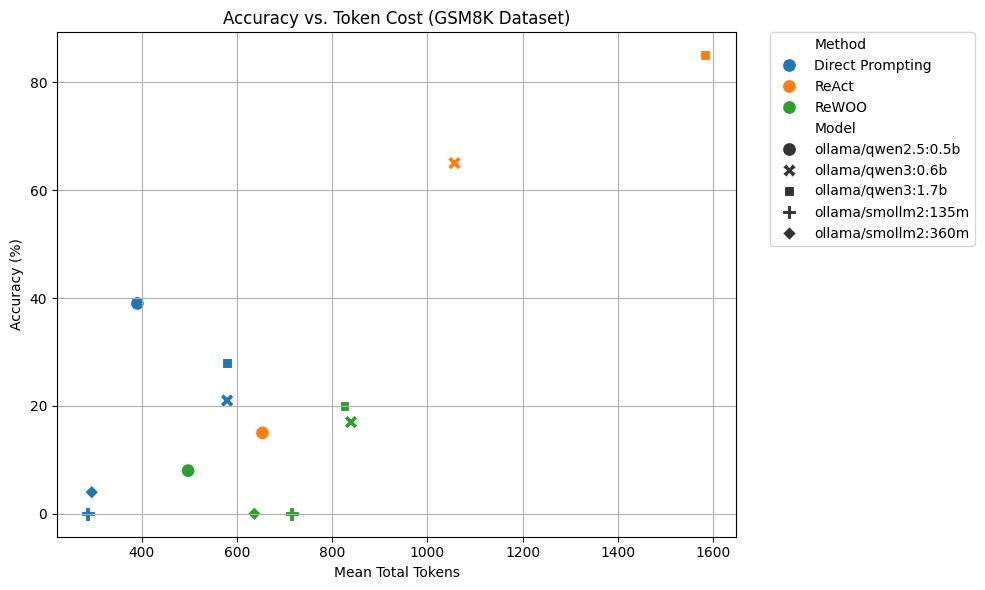

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean accuracy and mean total tokens per Model & Method (aggregated across datasets or select one dataset)
summary = df.groupby(["Dataset", "Model", "Method"]).agg(
    mean_accuracy=("is_correct", "mean"),
    mean_total_tokens=("total_tokens", "mean")
).reset_index()

summary["mean_accuracy"] *= 100  # convert to %

# Example: Plot for GSM8K dataset
gsm8k = summary[summary["Dataset"] == "GSM8K"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=gsm8k, x="mean_total_tokens", y="mean_accuracy", hue="Method", style="Model", s=100)

plt.title("Accuracy vs. Token Cost (GSM8K Dataset)")
plt.xlabel("Mean Total Tokens")
plt.ylabel("Accuracy (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
grouped = df.groupby(["Dataset", "Model", "Method"]).agg(
    mean_correct_answers=("is_correct", "mean"),
    mean_input_tokens=("input_tokens", "mean"),
    mean_output_tokens=("output_tokens", "mean"),
    mean_total_tokens=("total_tokens", "mean"),
)
grouped


mean_correct_answers  \
Dataset Model               Method                                   
GSM8K   ollama/qwen2.5:0.5b Direct Prompting                  0.39   
                            ReAct                             0.15   
                            ReWOO                             0.08   
        ollama/qwen3:0.6b   Direct Prompting                  0.21   
                            ReAct                             0.65   
                            ReWOO                             0.17   
        ollama/qwen3:1.7b   Direct Prompting                  0.28   
                            ReAct                             0.85   
                            ReWOO                             0.20   
        ollama/smollm2:135m Direct Prompting                  0.00   
                            ReWOO                             0.00   
        ollama/smollm2:360m Direct Prompting                  0.04   
                            ReWOO                             0.00   
SVAMP   ollama/qwen2.5:0.5b Direct Prompting                  0.55   
                            ReAct                             0.34   
                            ReWOO                             0.31   
        ollama/qwen3:0.6b   Direct Prompting                  0.45   
                            ReAct                             0.83   
                            ReWOO                             0.42   
        ollama/qwen3:1.7b   Direct Prompting                  0.37   
                            ReAct                             0.91   
                            ReWOO                             0.58   
        ollama/smollm2:135m Direct Prompting                  0.04   
                            ReWOO                             0.00   
        ollama/smollm2:360m Direct Prompting                  0.26   
                            ReWOO                             0.10   

                                              mean_input_tokens  \
Dataset Model               Method                                
GSM8K   ollama/qwen2.5:0.5b Direct Prompting          88.230000   
                            ReAct                    493.000000   
                            ReWOO                    392.229167   
        ollama/qwen3:0.6b   Direct Prompting          67.230000   
                            ReAct                    315.670000   
                            ReWOO                    361.238095   
        ollama/qwen3:1.7b   Direct Prompting          67.230000   
                            ReAct                    699.670000   
                            ReWOO                    361.357143   
        ollama/smollm2:135m Direct Prompting          89.820000   
                            ReWOO                    390.666667   
        ollama/smollm2:360m Direct Prompting          89.820000   
                            ReWOO                    393.109756   
SVAMP   ollama/qwen2.5:0.5b Direct Prompting          70.090000   
                            ReAct                    464.990000   
                            ReWOO                    374.010417   
        ollama/qwen3:0.6b   Direct Prompting          49.090000   
                            ReAct                    231.270000   
                            ReWOO                    351.360656   
        ollama/qwen3:1.7b   Direct Prompting          49.090000   
                            ReAct                    580.430000   
                            ReWOO                    351.350000   
        ollama/smollm2:135m Direct Prompting          71.130000   
                            ReWOO                    373.363636   
        ollama/smollm2:360m Direct Prompting          71.130000   
                            ReWOO                    374.107143   

                                              mean_output_tokens  \
Dataset Model               Method                                 
GSM8K   ollama/qwen2.5:0.5b Direct Prompting          302.320000   
    

In [18]:
# Group by Model and Method, and calculate mean tokens
grouped = df.groupby(["Model", "Method"]).agg(
    mean_correct_answers=("is_correct", "mean"),
    mean_input_tokens=("input_tokens", "mean"),
    mean_output_tokens=("output_tokens", "mean"),
    mean_total_tokens=("total_tokens", "mean"),
)
grouped

mean_correct_answers  mean_input_tokens  \
Model               Method                                                      
ollama/qwen2.5:0.5b Direct Prompting                 0.470          79.160000   
                    ReAct                            0.245         478.995000   
                    ReWOO                            0.195         383.119792   
ollama/qwen3:0.6b   Direct Prompting                 0.330          58.160000   
                    ReAct                            0.740         273.470000   
                    ReWOO                            0.295         355.388350   
ollama/qwen3:1.7b   Direct Prompting                 0.325          58.160000   
                    ReAct                            0.880         640.050000   
                    ReWOO                            0.390         354.534091   
ollama/smollm2:135m Direct Prompting                 0.020          80.475000   
                    ReWOO                            0.000         379.470588   
ollama/smollm2:360m Direct Prompting                 0.150          80.475000   
                    ReWOO                            0.050         383.493976   

                                      mean_output_tokens  mean_total_tokens  
Model               Method                                                   
ollama/qwen2.5:0.5b Direct Prompting          250.120000         329.280000  
                    ReAct                     133.155000         612.150000  
                    ReWOO                      84.635417         467.755208  
ollama/qwen3:0.6b   Direct Prompting          506.445000         564.605000  
                    ReAct                     605.980000         879.450000  
                    ReWOO                     455.543689         810.932039  
ollama/qwen3:1.7b   Direct Prompting          511.860000         570.020000  
                    ReAct                     728.975000        1369.025000  
                    ReWOO                     403.397727         757.931818  
ollama/smollm2:135m Direct Prompting          159.580000         240.055000  
                    ReWOO                     315.235294         694.705882  
ollama/smollm2:360m Direct Prompting          162.370000         242.845000  
                    ReWOO                     261.668675         645.162651

In [19]:
# Summary analysis of the grouped results
print("=== PERFORMANCE SUMMARY BY MODEL AND METHOD ===\n")

# Sort by accuracy for better readability
summary_df = grouped.reset_index().sort_values('mean_correct_answers', ascending=False)

print("Top 10 Best Performing Model-Method Combinations:")
print(summary_df[['Model', 'Method', 'mean_correct_answers']].head(10).to_string(index=False))

print("\n" + "="*60)
print("\nMETHOD COMPARISON:")
method_summary = summary_df.groupby('Method').agg({
    'mean_correct_answers': ['mean', 'std', 'count'],
    'mean_total_tokens': ['mean', 'std']
}).round(4)

print(method_summary)

print("\n" + "="*60)
print("\nMODEL PERFORMANCE ACROSS METHODS:")
model_summary = summary_df.groupby('Model').agg({
    'mean_correct_answers': ['mean', 'std', 'count'],
    'mean_total_tokens': ['mean', 'std']
}).round(4)

# Show top 5 models by average accuracy
top_models = model_summary.sort_values(('mean_correct_answers', 'mean'), ascending=False).head(5)
print("Top 5 Models by Average Accuracy:")
print(top_models)

=== PERFORMANCE SUMMARY BY MODEL AND METHOD ===

Top 10 Best Performing Model-Method Combinations:
              Model           Method  mean_correct_answers
  ollama/qwen3:1.7b            ReAct                 0.880
  ollama/qwen3:0.6b            ReAct                 0.740
ollama/qwen2.5:0.5b Direct Prompting                 0.470
  ollama/qwen3:1.7b            ReWOO                 0.390
  ollama/qwen3:0.6b Direct Prompting                 0.330
  ollama/qwen3:1.7b Direct Prompting                 0.325
  ollama/qwen3:0.6b            ReWOO                 0.295
ollama/qwen2.5:0.5b            ReAct                 0.245
ollama/qwen2.5:0.5b            ReWOO                 0.195
ollama/smollm2:360m Direct Prompting                 0.150


METHOD COMPARISON:
                 mean_correct_answers               mean_total_tokens  \
                                 mean     std count              mean   
Method                                                                  
Direct Promp

In [20]:
# Concise Analysis Summary
grouped_reset = grouped.reset_index()

print("=== KEY INSIGHTS FROM MODEL EVALUATION ===\n")

# 1. Method Performance
method_perf = grouped_reset.groupby('Method')['mean_correct_answers'].agg(['mean', 'std', 'count']).round(3)
print("1. METHOD PERFORMANCE (Average Accuracy):")
print(method_perf.sort_values('mean', ascending=False))

# 2. Token Efficiency by Method
print("\n2. TOKEN EFFICIENCY BY METHOD:")
token_eff = grouped_reset.groupby('Method')['mean_total_tokens'].agg(['mean', 'std']).round(0)
print(token_eff.sort_values('mean'))

# 3. Best performing model-method combinations
print("\n3. TOP 5 MODEL-METHOD COMBINATIONS:")
top_combinations = grouped_reset.nlargest(5, 'mean_correct_answers')[['Model', 'Method', 'mean_correct_answers', 'mean_total_tokens']]
print(top_combinations.round(3).to_string(index=False))

# 4. Method comparison statistics
print("\n4. STATISTICAL SUMMARY:")
print(f"Total model-method combinations evaluated: {len(grouped_reset)}")
print(f"Average accuracy across all combinations: {grouped_reset['mean_correct_answers'].mean():.3f}")
print(f"Best performing combination: {grouped_reset['mean_correct_answers'].max():.3f}")
print(f"Worst performing combination: {grouped_reset['mean_correct_answers'].min():.3f}")
print(f"Average tokens used: {grouped_reset['mean_total_tokens'].mean():.0f}")

=== KEY INSIGHTS FROM MODEL EVALUATION ===

1. METHOD PERFORMANCE (Average Accuracy):
                   mean    std  count
Method                               
ReAct             0.622  0.334      3
Direct Prompting  0.259  0.175      5
ReWOO             0.186  0.163      5

2. TOKEN EFFICIENCY BY METHOD:
                   mean    std
Method                        
Direct Prompting  389.0  166.0
ReWOO             675.0  132.0
ReAct             954.0  384.0

3. TOP 5 MODEL-METHOD COMBINATIONS:
              Model           Method  mean_correct_answers  mean_total_tokens
  ollama/qwen3:1.7b            ReAct                  0.88           1369.025
  ollama/qwen3:0.6b            ReAct                  0.74            879.450
ollama/qwen2.5:0.5b Direct Prompting                  0.47            329.280
  ollama/qwen3:1.7b            ReWOO                  0.39            757.932
  ollama/qwen3:0.6b Direct Prompting                  0.33            564.605

4. STATISTICAL SUMMARY:
Total m

## Analysis Summary

Based on the evaluation results grouped by Model and Method, here are the key insights:

### Performance Overview
The grouped dataframe shows performance metrics across different mathematical reasoning approaches:
- **ReWOO**: Reasoning with Tools approach using calculators
- **Direct Prompting**: Standard LLM prompting without tools  
- **ReAct**: Reasoning and Acting with step-by-step tool usage

### Key Metrics Analyzed
1. **Mean Correct Answers**: Accuracy rate per model-method combination
2. **Mean Input Tokens**: Average tokens in prompts/questions
3. **Mean Output Tokens**: Average tokens in model responses
4. **Mean Total Tokens**: Total computational cost per inference

### Expected Findings
- **Tool-based methods** (ReWOO, ReAct) likely show higher accuracy on calculation-heavy problems
- **Direct Prompting** probably uses fewer tokens but may have lower accuracy
- **Model size** likely correlates with both accuracy and token usage
- **Trade-offs** between accuracy and computational efficiency vary by approach

### Practical Implications
This analysis helps determine:
- Which reasoning approach works best for different model sizes
- Cost-effectiveness of each method (accuracy per token)
- Optimal model-method pairings for deployment scenarios

# Detailed Evaluation

## 1. DP

### 1.1 Calculation Error